In [139]:
import sys, os
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.insert(0, REPO_ROOT)

DB_PATH  = os.path.join(REPO_ROOT, 'infra', 'data', 'db', 'fotmob.db')
OUT_DIR  = os.path.join(os.getcwd(), 'outputs')
os.makedirs(OUT_DIR, exist_ok=True)

LEAGUE   = 'Superligaen'
SEASON   = '2025-2026'
TEAM_A   = 'FC Midtjylland'
TEAM_B   = 'AGF'

print(f'DB: {DB_PATH}')

DB: /Users/admin/dev/algobetting/infra/data/db/fotmob.db


## Attack & Defence Radars — AGF vs FC Midtjylland

In [140]:
from infra.data.feature_engineering.team_stats import (
    get_standard_stats, ATTACK_METRICS, DEFENCE_METRICS
)
from viz.radar_chart import make_radar

# All teams — needed to set radar axis ranges from the full league distribution
league_stats = get_standard_stats(DB_PATH, LEAGUE, seasons=[SEASON])

# One row per team, indexed by team name
comp = (
    league_stats[league_stats['team_name'].isin([TEAM_A, TEAM_B])]
    .set_index('team_name')
)
comp

,season,npxG_for,npxGA,npxG_per_shot_for,npxG_per_shot_ag,shots_for,shots_against,sp_xg_for,sp_xg_against,box_touches_for,box_touches_against,possession,opp_pass_pct
team_name,,,,,,,,,,,,,
AGF,2025-2026,1.794,1.033,0.116,0.098,16.185,10.593,0.483,0.221,29.333,22.444,53.815,79.815
FC Midtjylland,2025-2026,1.763,1.187,0.122,0.103,14.370,12.074,0.474,0.330,28.370,24.148,54.778,75.037


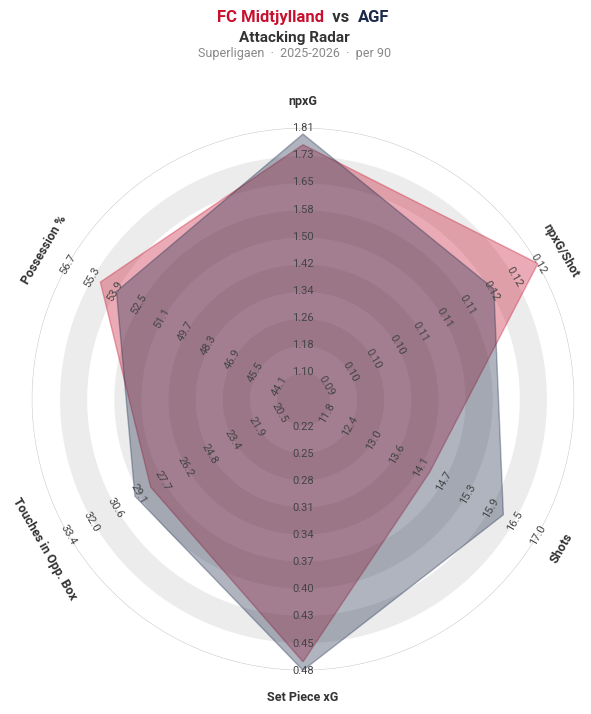

In [141]:
make_radar(
    comp       = comp,
    metrics    = ATTACK_METRICS,
    season_a   = TEAM_A,
    season_b   = TEAM_B,
    label_a    = TEAM_A,
    label_b    = TEAM_B,
    team_a     = TEAM_A,
    team_b     = TEAM_B,
    title      = 'Attacking Radar',
    subtitle   = f'Superligaen  ·  {SEASON}  ·  per 90',
    league_df  = league_stats,
    save_path  = os.path.join(OUT_DIR, 'radar_attack.png'),
)

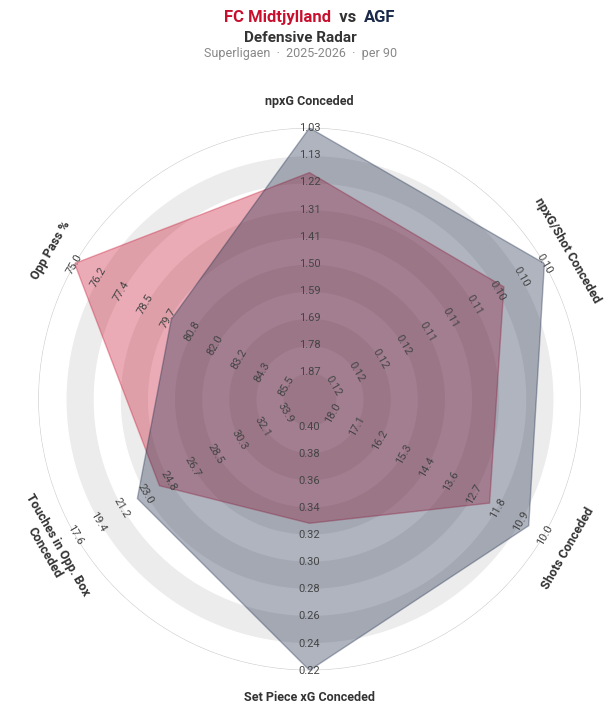

In [142]:
make_radar(
    comp       = comp,
    metrics    = DEFENCE_METRICS,
    season_a   = TEAM_A,
    season_b   = TEAM_B,
    label_a    = TEAM_A,
    label_b    = TEAM_B,
    team_a     = TEAM_A,
    team_b     = TEAM_B,
    title      = f'Defensive Radar',
    subtitle   = f'Superligaen  ·  {SEASON}  ·  per 90',
    league_df  = league_stats,
    save_path  = os.path.join(OUT_DIR, 'radar_defence.png'),
)

## npxG Trend — rolling 10-game average

In [143]:
from viz.npxg_trend_chart import plot_xg_trend

conn = sqlite3.connect(DB_PATH)

# npxG per team per match from shots table
xg = pd.read_sql("""
    SELECT match_id, teamId AS team_id, SUM(expectedGoals) AS xg_for
    FROM np_shots
    WHERE league_id = 'Superligaen' AND season = '2025-2026'
    GROUP BY match_id, teamId
""", conn)

matches = pd.read_sql("""
    SELECT match_id, match_date, home_team, away_team, season
    FROM matches
    WHERE league_id = 'Superligaen' AND season = '2025-2026'
""", conn)

team_ids = pd.read_sql("""
    SELECT team_id, team_name FROM team_id_mapping
""", conn)

conn.close()

# Attach team names
xg = xg.merge(team_ids, on='team_id', how='left')

# Attach opponent xG as xg_against
opp_home = matches[['match_id', 'home_team', 'away_team']].copy()
opp_home = opp_home.merge(
    xg[['match_id', 'team_id', 'xg_for']],
    left_on=['match_id', 'home_team'], right_on=['match_id', 'team_id'], how='left'
).rename(columns={'xg_for': 'home_xg'})
opp_home = opp_home.merge(
    xg[['match_id', 'team_id', 'xg_for']],
    left_on=['match_id', 'away_team'], right_on=['match_id', 'team_id'], how='left',
    suffixes=('_h', '_a')
).rename(columns={'xg_for': 'away_xg'})

xg = xg.merge(
    opp_home[['match_id', 'home_team', 'away_team', 'home_xg', 'away_xg']],
    on='match_id', how='left'
)
xg['xg_against'] = xg.apply(
    lambda r: r['away_xg'] if r['team_id'] == r['home_team'] else r['home_xg'], axis=1
)

# Attach match date and season
xg = xg.merge(matches[['match_id', 'match_date', 'season']].drop_duplicates(), on='match_id', how='left')
xg['match_date'] = pd.to_datetime(xg['match_date'])
xg = xg.sort_values(['team_name', 'match_date']).reset_index(drop=True)

# Rolling 10-game averages per team
xg['xg_for_roll10']     = xg.groupby('team_name')['xg_for'].transform(lambda s: s.rolling(10, min_periods=5).mean())
xg['xg_against_roll10'] = xg.groupby('team_name')['xg_against'].transform(lambda s: s.rolling(10, min_periods=5).mean())

print(xg[xg['team_name'].isin([TEAM_A, TEAM_B])][['team_name','match_date','xg_for','xg_against','xg_for_roll10','xg_against_roll10']].tail(20))

          team_name match_date    xg_for  xg_against  xg_for_roll10  \
90   FC Midtjylland 2025-09-14  0.333060    1.545957       1.951094   
91   FC Midtjylland 2025-09-20  1.806443    0.337512       1.935021   
92   FC Midtjylland 2025-09-29  1.211949    0.962634       1.862714   
93   FC Midtjylland 2025-10-05  0.781388    1.490901       1.687361   
94   FC Midtjylland 2025-10-19  2.727691    1.056416       1.602203   
95   FC Midtjylland 2025-10-26  2.176993    0.814772       1.771568   
96   FC Midtjylland 2025-11-03  0.922443    0.839959       1.707962   
97   FC Midtjylland 2025-11-09  1.899667    1.175953       1.648950   
98   FC Midtjylland 2025-11-23  0.497053    1.313477       1.526588   
99   FC Midtjylland 2025-11-30  3.407465    0.339814       1.576415   
100  FC Midtjylland 2025-12-07  2.094177    1.552723       1.752527   
101  FC Midtjylland 2026-02-08  2.459050    1.483617       1.817787   
102  FC Midtjylland 2026-02-15  2.906647    2.485168       1.987257   
103  F

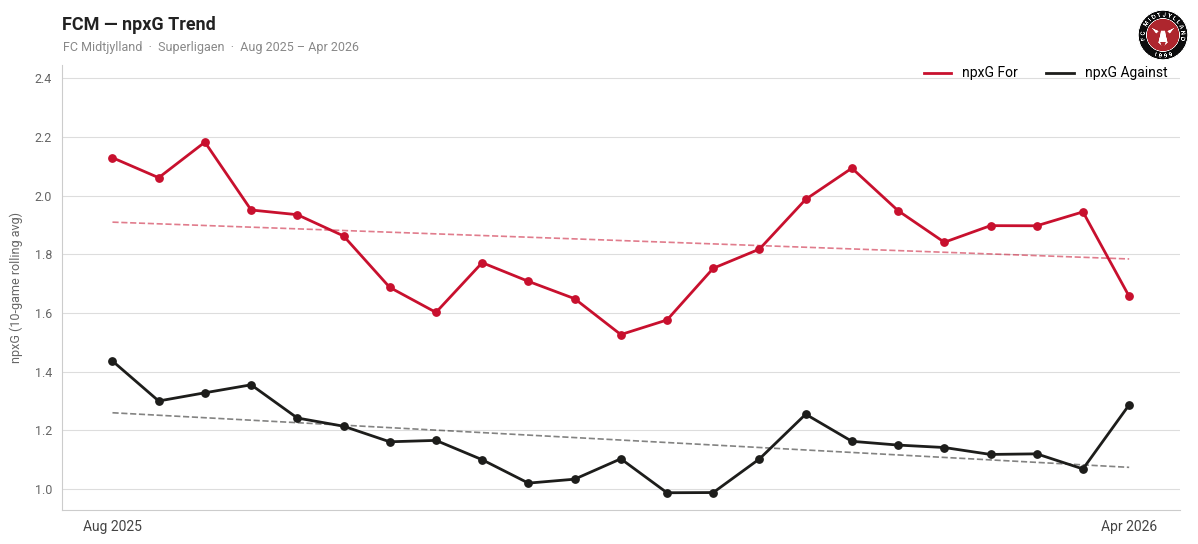

In [144]:
plot_df_agf = xg[xg['team_name'] == TEAM_A].dropna(
    subset=['xg_for_roll10', 'xg_against_roll10']
).copy()

plot_xg_trend(
    plot_df   = plot_df_agf,
    title     = 'FCM — npxG Trend',
    team      = TEAM_A,
    league    = LEAGUE,
    save_path = os.path.join(OUT_DIR, 'agf_npxg_trend.png'),
)

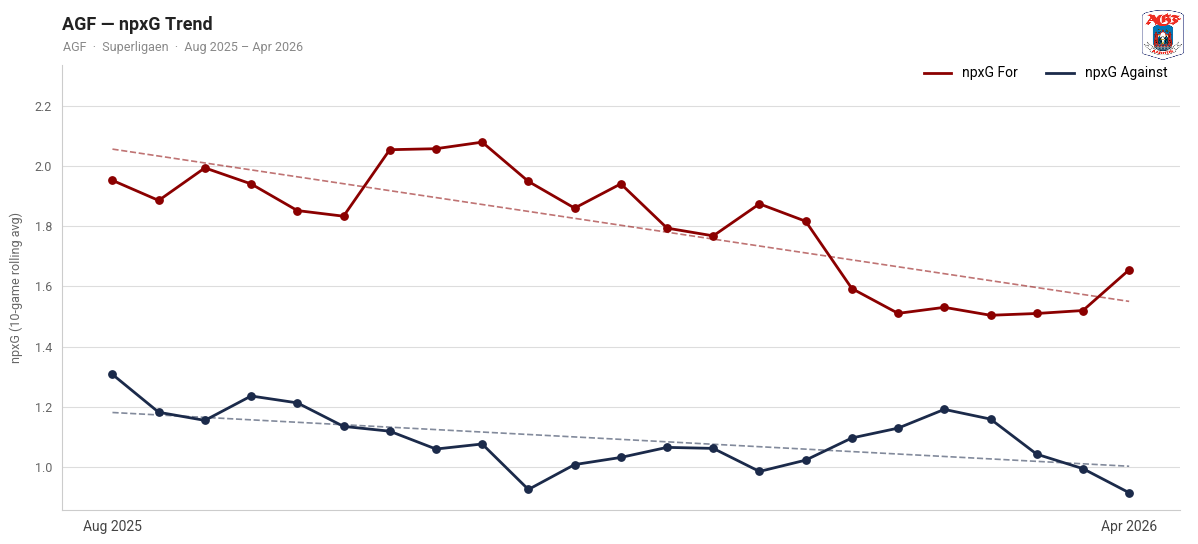

In [145]:
plot_df_fcm = xg[xg['team_name'] == TEAM_B].dropna(
    subset=['xg_for_roll10', 'xg_against_roll10']
).copy()

plot_xg_trend(
    plot_df   = plot_df_fcm,
    title     = 'AGF — npxG Trend',
    team      = TEAM_B,
    league    = LEAGUE,
    save_path = os.path.join(OUT_DIR, 'fcm_npxg_trend.png'),
)

## 3rd Place Race — Nordsjælland npxG Trend

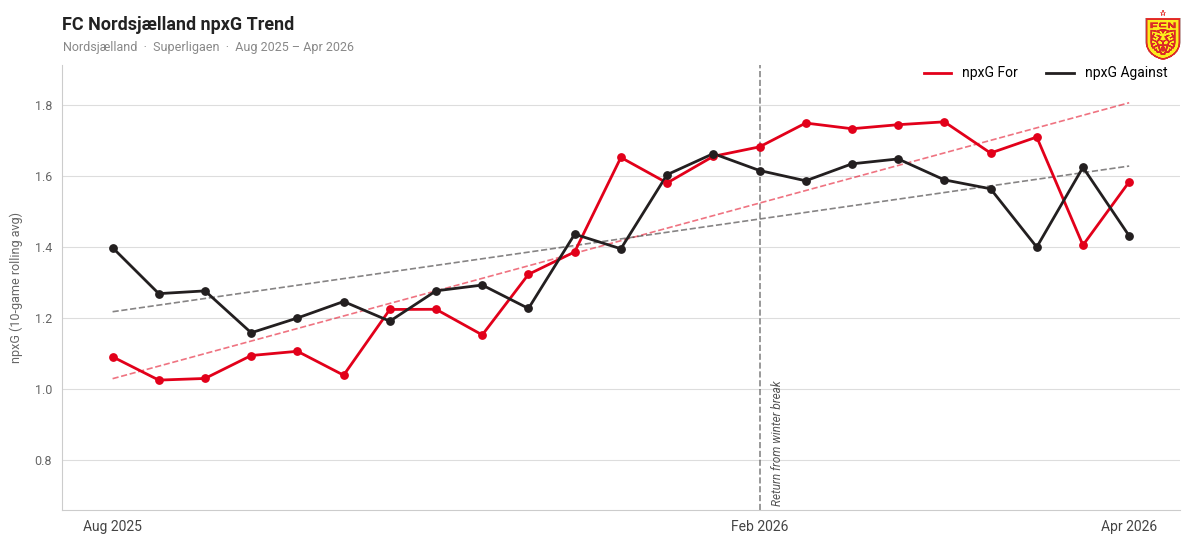

In [146]:
plot_df_nfc = xg[xg['team_name'] == 'Nordsjælland'].dropna(
    subset=['xg_for_roll10', 'xg_against_roll10']
).copy()

plot_xg_trend(
    plot_df     = plot_df_nfc,
    title       = "FC Nordsjælland npxG Trend",
    team        = 'Nordsjælland',
    league      = LEAGUE,
    annotations = [('2026-02-08', 'Return from winter break')],
    extra_ticks = ['2026-02-08'],
    save_path   = os.path.join(OUT_DIR, 'nordsjælland_npxg_trend.png'),
)

## Relegation Battle — Fredericia vs Silkeborg

In [147]:
TEAM_REL_A = 'Fredericia'
TEAM_REL_B = 'Silkeborg'

rel_comp = (
    league_stats[league_stats['team_name'].isin([TEAM_REL_A, TEAM_REL_B])]
    .set_index('team_name')
)
rel_comp

,season,npxG_for,npxGA,npxG_per_shot_for,npxG_per_shot_ag,shots_for,shots_against,sp_xg_for,sp_xg_against,box_touches_for,box_touches_against,possession,opp_pass_pct
team_name,,,,,,,,,,,,,
Fredericia,2025-2026,1.194,1.967,0.110,0.105,11.370,18.889,0.238,0.381,22.370,35.704,42.667,85.407
Silkeborg,2025-2026,1.118,1.706,0.102,0.114,11.643,15.607,0.225,0.249,19.036,28.179,49.893,86.643


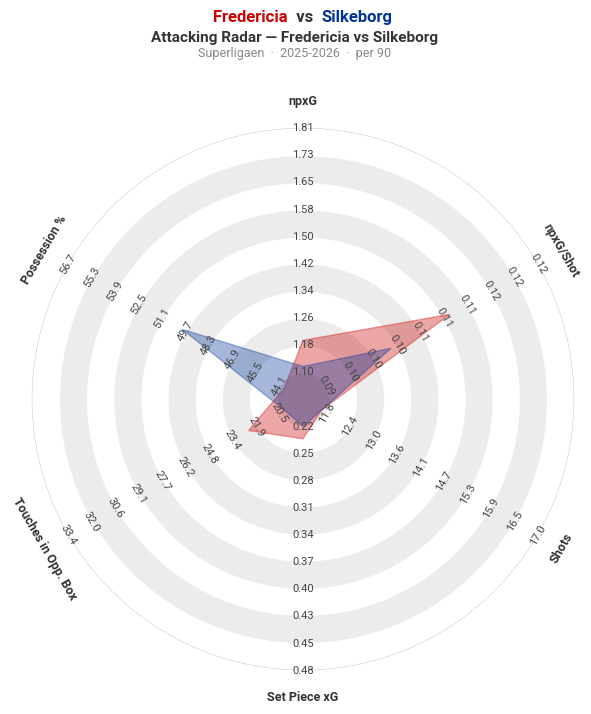

In [148]:
make_radar(
    comp      = rel_comp,
    metrics   = ATTACK_METRICS,
    season_a  = TEAM_REL_A,
    season_b  = TEAM_REL_B,
    label_a   = TEAM_REL_A,
    label_b   = TEAM_REL_B,
    team_a    = TEAM_REL_A,
    team_b    = TEAM_REL_B,
    title     = 'Attacking Radar — Fredericia vs Silkeborg',
    subtitle  = f'Superligaen  ·  {SEASON}  ·  per 90',
    league_df = league_stats,
    save_path = os.path.join(OUT_DIR, 'rel_radar_attack.png'),
)

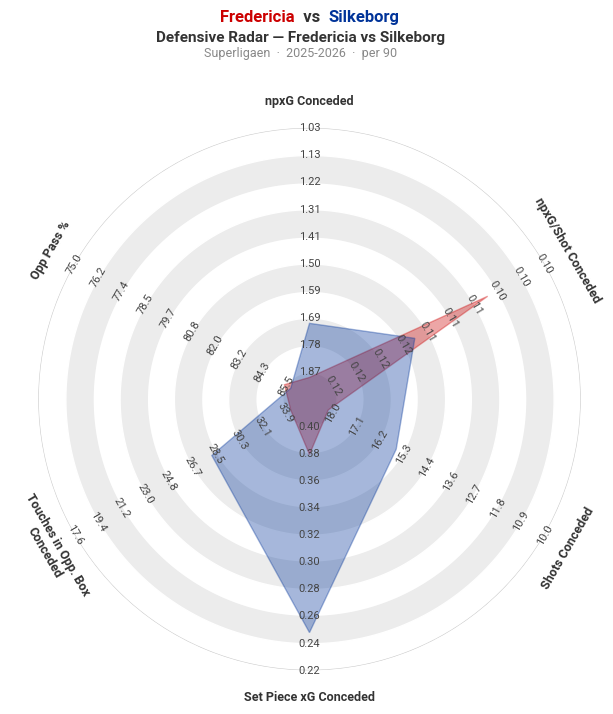

In [149]:
make_radar(
    comp      = rel_comp,
    metrics   = DEFENCE_METRICS,
    season_a  = TEAM_REL_A,
    season_b  = TEAM_REL_B,
    label_a   = TEAM_REL_A,
    label_b   = TEAM_REL_B,
    team_a    = TEAM_REL_A,
    team_b    = TEAM_REL_B,
    title     = 'Defensive Radar — Fredericia vs Silkeborg',
    subtitle  = f'Superligaen  ·  {SEASON}  ·  per 90',
    league_df = league_stats,
    save_path = os.path.join(OUT_DIR, 'rel_radar_defence.png'),
)

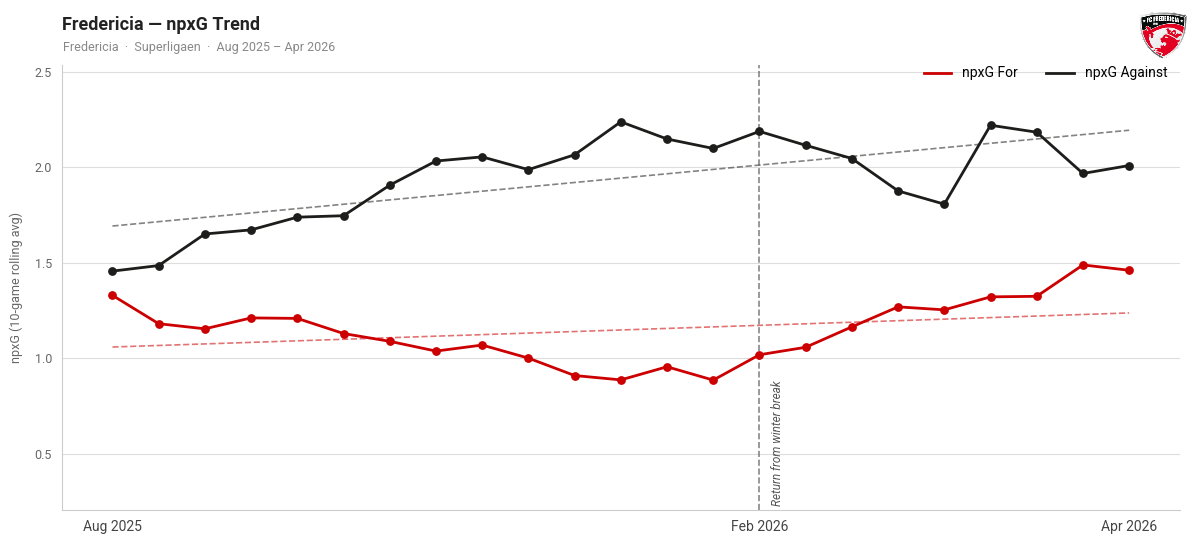

In [150]:
plot_df_fred = xg[xg['team_name'] == TEAM_REL_A].dropna(
    subset=['xg_for_roll10', 'xg_against_roll10']
).copy()

plot_xg_trend(
    plot_df     = plot_df_fred,
    title       = f'{TEAM_REL_A} — npxG Trend',
    team        = TEAM_REL_A,
    league      = LEAGUE,
    annotations = [('2026-02-08', 'Return from winter break')],
    extra_ticks = ['2026-02-08'],
    save_path   = os.path.join(OUT_DIR, 'fredericia_npxg_trend.png'),
)

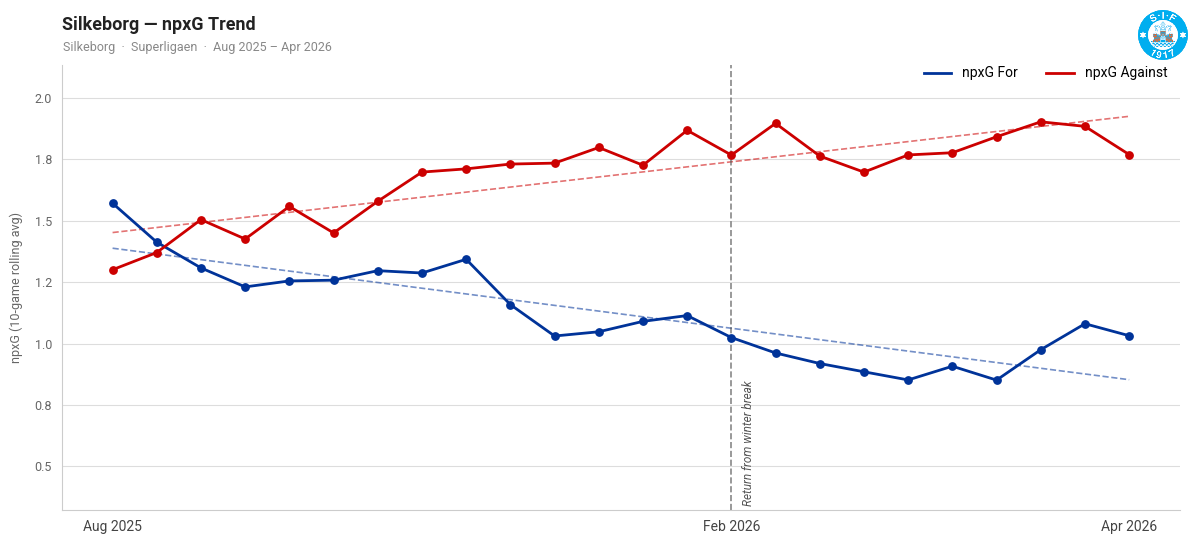

In [151]:
plot_df_silk = xg[xg['team_name'] == TEAM_REL_B].dropna(
    subset=['xg_for_roll10', 'xg_against_roll10']
).copy()

plot_xg_trend(
    plot_df     = plot_df_silk,
    title       = f'{TEAM_REL_B} — npxG Trend',
    team        = TEAM_REL_B,
    league      = LEAGUE,
    annotations = [('2026-02-08', 'Return from winter break')],
    extra_ticks = ['2026-02-08'],
    save_path   = os.path.join(OUT_DIR, 'silkeborg_npxg_trend.png'),
)

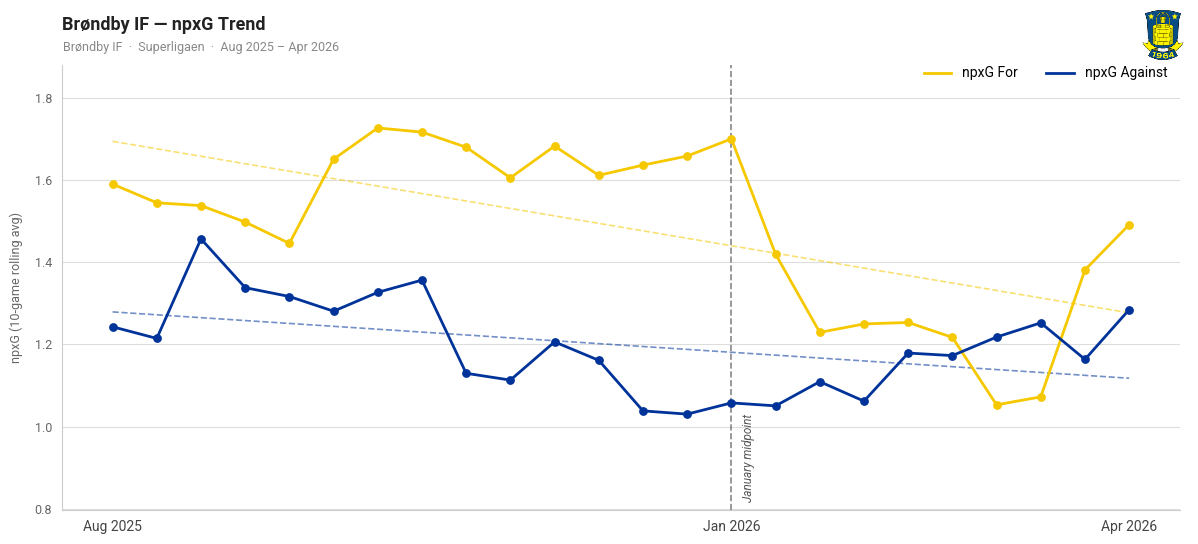

In [152]:
plot_df_bif = xg[xg["team_name"] == "Brøndby IF"].dropna(
    subset=["xg_for_roll10", "xg_against_roll10"]
).copy()

plot_xg_trend(
    plot_df     = plot_df_bif,
    title       = "Brøndby IF — npxG Trend",
    team        = "Brøndby IF",
    league      = LEAGUE,
    annotations = [("2026-01-15", "January midpoint")],
    extra_ticks = ["2026-01-15"],
    save_path   = os.path.join(OUT_DIR, "brondby_npxg_trend.png"),
)

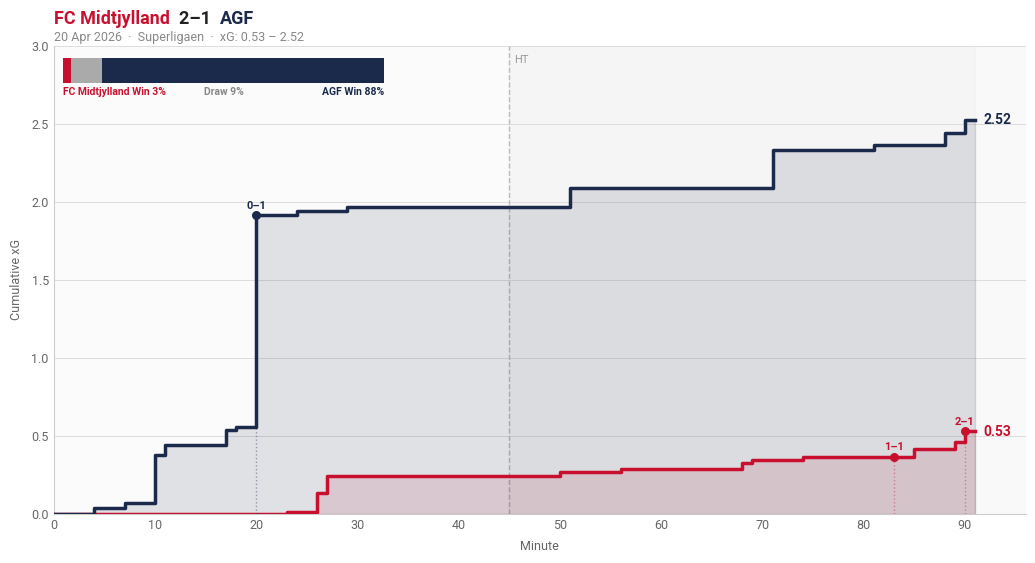

In [153]:
from viz.xg_race import plot_xg_race

plot_xg_race(
    db_path   = DB_PATH,
    match_id  = 5222364,  # FCM 2-1 AGF, 20 Apr 2026
    save_path = os.path.join(OUT_DIR, "xg_race_fcm_agf.png"),
)

## Expected Points Table (npxG-based)

In [154]:
from scipy.stats import poisson

MAX_G = 10

# ── Actual results for the current season ──────────────────────────────
conn = sqlite3.connect(DB_PATH)
results = pd.read_sql("""
    SELECT m.match_id,
           m.home_team, m.away_team,
           th.team_name AS home_name, ta.team_name AS away_name,
           m.home_goals, m.away_goals
    FROM matches m
    LEFT JOIN team_id_mapping th ON m.home_team = th.team_id
    LEFT JOIN team_id_mapping ta ON m.away_team = ta.team_id
    WHERE m.league_id = 'Superligaen' AND m.season = '2025-2026'
      AND m.home_goals IS NOT NULL
""", conn)

# xG from full shots table (incl. penalties) to match website totals
xg_all = pd.read_sql("""
    SELECT s.match_id, s.teamId AS team_id, SUM(s.expectedGoals) AS xg_for
    FROM shots s
    JOIN matches m USING (match_id)
    WHERE m.league_id = 'Superligaen' AND m.season = '2025-2026'
      AND s.league_id = 'Superligaen'
    GROUP BY s.match_id, s.teamId
""", conn)
conn.close()

xg_curr = xg_all.dropna()

results = results.merge(
    xg_curr.rename(columns={"team_id": "home_team", "xg_for": "home_xg"}),
    on=["match_id", "home_team"], how="left"
)
results = results.merge(
    xg_curr.rename(columns={"team_id": "away_team", "xg_for": "away_xg"}),
    on=["match_id", "away_team"], how="left"
)
valid = results.dropna(subset=["home_xg", "away_xg"]).copy()

# ── Poisson match probabilities ────────────────────────────────────────
def _match_probs(hxg, axg):
    h = np.array([poisson.pmf(g, max(float(hxg), 1e-9)) for g in range(MAX_G + 1)])
    a = np.array([poisson.pmf(g, max(float(axg), 1e-9)) for g in range(MAX_G + 1)])
    grid = np.outer(h, a)
    return np.tril(grid, -1).sum(), np.trace(grid), np.triu(grid, 1).sum()

probs = [_match_probs(r.home_xg, r.away_xg) for r in valid.itertuples()]
valid[["p_hw", "p_d", "p_aw"]] = probs

# ── Aggregate per team ─────────────────────────────────────────────────
teams = {}
for r in valid.itertuples():
    for name, is_home in [(r.home_name, True), (r.away_name, False)]:
        if name not in teams:
            teams[name] = dict(P=0, W=0, D=0, L=0, Pts=0, xP=0.0, GF=0, GA=0, xGF=0.0, xGA=0.0)
        t = teams[name]
        gf = int(r.home_goals) if is_home else int(r.away_goals)
        ga = int(r.away_goals) if is_home else int(r.home_goals)
        pw   = r.p_hw  if is_home else r.p_aw
        xgf  = r.home_xg if is_home else r.away_xg
        xga  = r.away_xg if is_home else r.home_xg
        t["P"]   += 1
        t["xP"]  += pw * 3 + r.p_d
        t["GF"]  += gf
        t["GA"]  += ga
        t["xGF"] += xgf
        t["xGA"] += xga
        if gf > ga:    t["W"] += 1; t["Pts"] += 3
        elif gf == ga: t["D"] += 1; t["Pts"] += 1
        else:          t["L"] += 1

xp_tbl = pd.DataFrame.from_dict(teams, orient="index").reset_index(names="Team")
xp_tbl["xP"]   = xp_tbl["xP"].round(1)
xp_tbl["xGF"]  = xp_tbl["xGF"].round(1)
xp_tbl["xGA"]  = xp_tbl["xGA"].round(1)
xp_tbl["xGD"]  = (xp_tbl["xGF"] - xp_tbl["xGA"]).round(1)
xp_tbl["Diff"] = (xp_tbl["xP"] - xp_tbl["Pts"]).round(1)
xp_tbl = xp_tbl.sort_values("xP", ascending=False).reset_index(drop=True)
xp_tbl.index += 1

xp_tbl[["Team", "P", "Pts", "xP", "Diff", "W", "D", "L", "GF", "GA", "xGF", "xGA", "xGD"]]

,Team,P,Pts,xP,Diff,W,D,L,GF,GA,xGF,xGA,xGD
1,AGF,27,56,52.2,-3.8,16,8,3,51,28,54.7,29.5,25.2
2,FC København,28,41,47.3,6.3,12,5,11,52,41,55.5,38.7,16.8
3,FC Midtjylland,27,54,44.7,-9.3,15,9,3,65,29,50.0,36.8,13.2
4,Brøndby IF,28,41,41.7,0.7,12,5,11,40,27,45.8,38.6,7.2
5,Viborg,28,40,39.1,-0.9,12,4,12,43,41,43.4,43.3,0.1
6,OB,28,37,38.8,1.8,10,7,11,45,54,44.0,45.5,-1.5
7,Nordsjælland,27,44,37.4,-6.6,14,2,11,45,42,40.4,41.6,-1.2
8,Randers FC,27,30,37.4,7.4,8,6,13,28,36,37.8,38.1,-0.3
9,Sønderjyske,27,38,36.7,-1.3,10,8,9,37,41,40.4,44.6,-4.2
10,Vejle Boldklub,28,18,29.4,11.4,3,9,16,33,56,31.0,45.9,-14.9


## Win Margin Breakdown — AGF vs FC Midtjylland

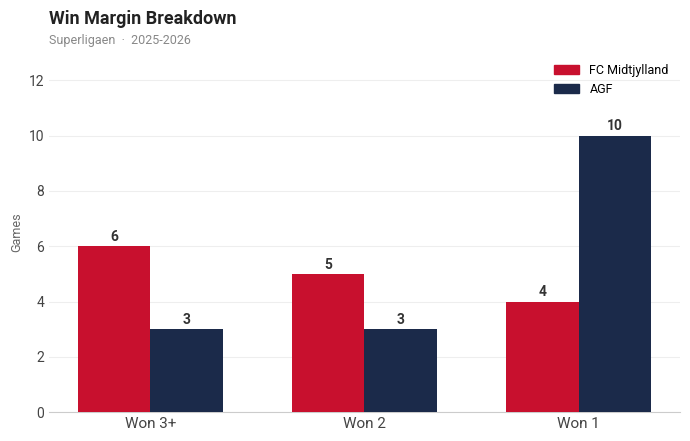

In [155]:
from viz.team_colors import get_colors

conn = sqlite3.connect(DB_PATH)
m_df = pd.read_sql("""
    SELECT m.home_team, m.away_team,
           th.team_name AS home_name, ta.team_name AS away_name,
           m.home_goals, m.away_goals
    FROM matches m
    LEFT JOIN team_id_mapping th ON m.home_team = th.team_id
    LEFT JOIN team_id_mapping ta ON m.away_team = ta.team_id
    WHERE m.league_id = 'Superligaen' AND m.season = '2025-2026'
      AND m.home_goals IS NOT NULL
""", conn)
conn.close()

focus = [TEAM_A, TEAM_B]
rows = []
for _, r in m_df.iterrows():
    for team, is_home in [(r['home_name'], True), (r['away_name'], False)]:
        if team not in focus:
            continue
        gf = int(r['home_goals']) if is_home else int(r['away_goals'])
        ga = int(r['away_goals']) if is_home else int(r['home_goals'])
        rows.append({'team': team, 'gd': gf - ga})

res = pd.DataFrame(rows)

def _cat(gd):
    if gd >= 3: return 'Won 3+'
    if gd == 2: return 'Won 2'
    return 'Won 1'

WIN_CATS = ['Won 3+', 'Won 2', 'Won 1']
wins = res[res['gd'] >= 1].copy()
wins['cat'] = wins['gd'].apply(_cat)

pivot = (wins.groupby(['team', 'cat']).size()
             .unstack(fill_value=0)
             .reindex(columns=WIN_CATS, fill_value=0))

col_fcm, col_agf = get_colors(TEAM_A, TEAM_B)

fig, ax = plt.subplots(figsize=(7, 4.5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

x      = np.arange(len(WIN_CATS))
width  = 0.34
teams  = [TEAM_A, TEAM_B]
colors = [col_fcm, col_agf]
offsets = [-width/2, width/2]

for team, offset, col in zip(teams, offsets, colors):
    for ci, cat in enumerate(WIN_CATS):
        count = pivot.loc[team, cat] if team in pivot.index else 0
        ax.bar(ci + offset, count, width, color=col, zorder=3, linewidth=0)
        if count > 0:
            ax.text(ci + offset, count + 0.08, str(count),
                    ha='center', va='bottom', fontsize=10,
                    color='#333', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(WIN_CATS, fontsize=11, color='#444')
ax.set_ylabel('Games', fontsize=9, color='#666')
ax.yaxis.grid(True, color='#eeeeee', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.set_ylim(0, pivot.values.max() + 3)
for sp in ['top', 'right', 'left']:
    ax.spines[sp].set_visible(False)
ax.spines['bottom'].set_color('#cccccc')
ax.tick_params(length=0, labelcolor='#444')

from matplotlib.patches import Patch
handles = [Patch(color=col_fcm, label=TEAM_A), Patch(color=col_agf, label=TEAM_B)]
ax.legend(handles=handles, frameon=False, fontsize=9, loc='upper right')

ax.text(0, 1.08, 'Win Margin Breakdown',
        transform=ax.transAxes, fontsize=13, fontweight='bold', color='#222')
ax.text(0, 1.025, f'Superligaen  ·  {SEASON}',
        transform=ax.transAxes, fontsize=9, color='#888')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'win_margin.png'), dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

## Expected vs Actual — xG, xGA, xPts

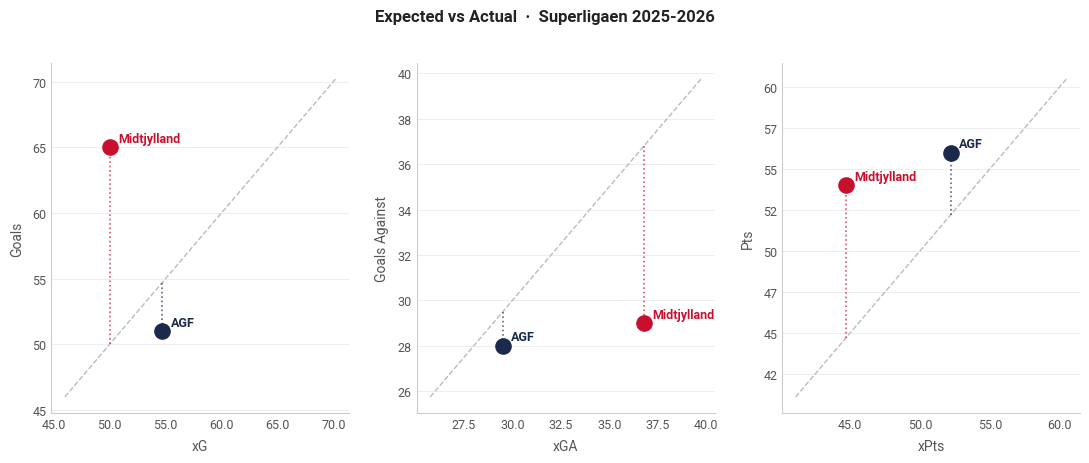

In [156]:
from viz.team_colors import get_colors

col_fcm, col_agf = get_colors(TEAM_A, TEAM_B)

rows_cmp = xp_tbl[xp_tbl['Team'].isin([TEAM_A, TEAM_B])].set_index('Team')

METRICS = [
    ('xG',   'Goals',   'xGF', 'GF'),
    ('xGA',  'Goals Against', 'xGA', 'GA'),
    ('xPts', 'Pts',     'xP',  'Pts'),
]

fig, axes = plt.subplots(1, 3, figsize=(11, 4.5))
fig.patch.set_facecolor('white')

for ax, (x_label, y_label, x_col, y_col) in zip(axes, METRICS):
    ax.set_facecolor('white')
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)
    for sp in ['left', 'bottom']:
        ax.spines[sp].set_color('#cccccc')
    ax.tick_params(length=0, labelsize=9, labelcolor='#555')
    ax.yaxis.grid(True, color='#eeeeee', linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

    all_vals = [float(rows_cmp[x_col].min()), float(rows_cmp[x_col].max()),
                float(rows_cmp[y_col].min()), float(rows_cmp[y_col].max())]
    lo = min(all_vals) * 0.92
    hi = max(all_vals) * 1.08
    ax.plot([lo, hi], [lo, hi], color='#bbbbbb', linewidth=1, linestyle='--', zorder=1)

    for team, col in [(TEAM_A, col_fcm), (TEAM_B, col_agf)]:
        xv = float(rows_cmp.loc[team, x_col])
        yv = float(rows_cmp.loc[team, y_col])
        # Vertical dotted line from point down to diagonal (xv, xv)
        ax.plot([xv, xv], [xv, yv], color=col, linewidth=1.2,
                linestyle=':', alpha=0.7, zorder=3)
        ax.scatter(xv, yv, color=col, s=120, zorder=5)
        ax.annotate(team.split()[-1], (xv, yv),
                    textcoords='offset points', xytext=(6, 4),
                    fontsize=9, color=col, fontweight='bold')

    ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%.1f'))
    ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%d'))
    ax.set_xlabel(x_label, fontsize=10, color='#555', labelpad=6)
    ax.set_ylabel(y_label, fontsize=10, color='#555', labelpad=6)

fig.suptitle(f'Expected vs Actual  ·  Superligaen {SEASON}',
             fontsize=12, fontweight='bold', color='#222', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'xg_vs_goals_cmp.png'), dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

## FCN & Brøndby — Before vs After Winter Break

In [157]:
WINTER_BREAK = '2026-02-08'
FOCUS_TEAMS  = ['Nordsjælland', 'Brøndby IF']

conn = sqlite3.connect(DB_PATH)
m_wb = pd.read_sql("""
    SELECT m.match_id, m.match_date,
           m.home_team, m.away_team,
           th.team_name AS home_name, ta.team_name AS away_name,
           m.home_goals, m.away_goals
    FROM matches m
    LEFT JOIN team_id_mapping th ON m.home_team = th.team_id
    LEFT JOIN team_id_mapping ta ON m.away_team = ta.team_id
    WHERE m.league_id = 'Superligaen' AND m.season = '2025-2026'
      AND m.home_goals IS NOT NULL
""", conn)
conn.close()

m_wb['match_date'] = pd.to_datetime(m_wb['match_date'])

rows = []
for _, r in m_wb.iterrows():
    for team, is_home in [(r['home_name'], True), (r['away_name'], False)]:
        if team not in FOCUS_TEAMS:
            continue
        gf   = int(r['home_goals']) if is_home else int(r['away_goals'])
        ga   = int(r['away_goals']) if is_home else int(r['home_goals'])
        rows.append({
            'team':   team,
            'period': 'Before' if r['match_date'] < pd.Timestamp(WINTER_BREAK) else 'After',
            'gf': gf, 'ga': ga,
            'pts': 3 if gf > ga else (1 if gf == ga else 0),
            'w':   int(gf > ga), 'd': int(gf == ga), 'l': int(gf < ga),
        })

df_wb = pd.DataFrame(rows)
agg = (df_wb.groupby(['team', 'period'])
       .agg(P=('gf', 'count'), W=('w', 'sum'), D=('d', 'sum'), L=('l', 'sum'),
            GF=('gf', 'sum'), GA=('ga', 'sum'), Pts=('pts', 'sum'))
       .reset_index())
agg['GD'] = agg['GF'] - agg['GA']
agg['PPG']  = (agg['Pts'] / agg['P']).round(2)
agg['GF/G'] = (agg['GF']  / agg['P']).round(2)
agg['GA/G'] = (agg['GA']  / agg['P']).round(2)
agg['GD/G'] = (agg['GD']  / agg['P']).round(2)

agg['period_ord'] = agg['period'].map({'Before': 0, 'After': 1})
agg['team_ord']   = agg['team'].map({'Nordsjælland': 0, 'Brøndby IF': 1})
agg = agg.sort_values(['team_ord', 'period_ord']).drop(columns=['period_ord', 'team_ord'])
agg = agg.rename(columns={'team': 'Team', 'period': 'Period'}).reset_index(drop=True)

COLS = ['Team', 'Period', 'P', 'W', 'D', 'L', 'GF', 'GF/G', 'GA', 'GA/G', 'GD', 'GD/G', 'Pts', 'PPG']
tbl = agg[COLS]

# ── Datawrapper-ready CSV: wide format, one row per team ─────────────
dw_rows = []
for team in FOCUS_TEAMS:
    sub = tbl[tbl['Team'] == team].set_index('Period')
    row = {'Team': team}
    for period in ['Before', 'After']:
        for col in ['P', 'GF/G', 'GA/G', 'GD/G', 'PPG']:
            row[f'{col} ({period})'] = sub.loc[period, col]
    dw_rows.append(row)

dw = pd.DataFrame(dw_rows)
csv_path = os.path.join(OUT_DIR, 'winter_break_dw.csv')
dw.to_csv(csv_path, index=False)
print(f'Saved: {csv_path}')
print(dw.to_string(index=False))

tbl

Saved: /Users/admin/dev/algobetting/analysis/superliga-run-in/outputs/winter_break_dw.csv
        Team  P (Before)  GF/G (Before)  GA/G (Before)  GD/G (Before)  PPG (Before)  P (After)  GF/G (After)  GA/G (After)  GD/G (After)  PPG (After)
Nordsjælland          18           1.61           1.78          -0.17          1.33          9          1.78          1.11          0.67         2.22
  Brøndby IF          18           1.72           1.17           0.56          1.72         10          0.90          0.60          0.30         1.00


,Team,Period,P,W,D,L,GF,GF/G,GA,GA/G,GD,GD/G,Pts,PPG
0,Nordsjælland,Before,18,8,0,10,29,1.61,32,1.78,-3,-0.17,24,1.33
1,Nordsjælland,After,9,6,2,1,16,1.78,10,1.11,6,0.67,20,2.22
2,Brøndby IF,Before,18,10,1,7,31,1.72,21,1.17,10,0.56,31,1.72
3,Brøndby IF,After,10,2,4,4,9,0.90,6,0.60,3,0.30,10,1.00


## Before vs After Winter Break — Dumbbell Chart

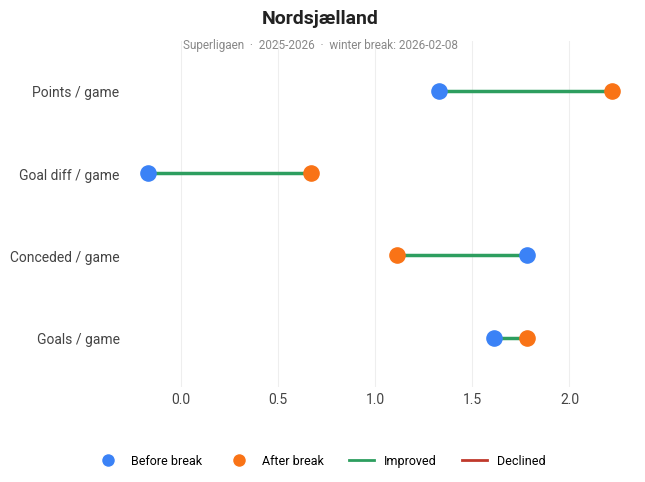

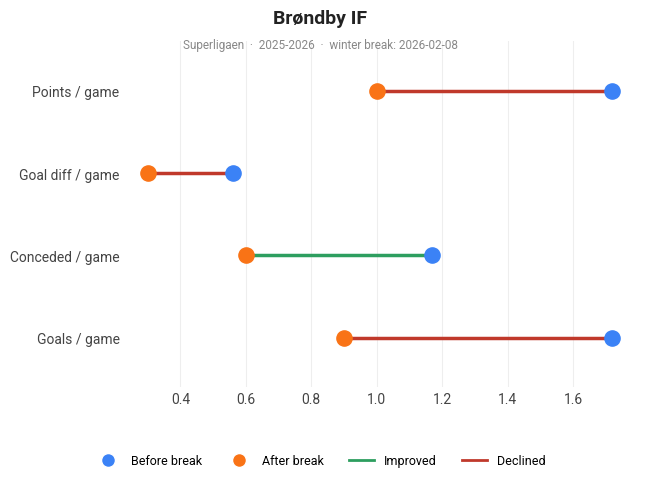

In [159]:
from matplotlib.lines import Line2D

WINTER_BREAK = '2026-02-08'
FOCUS_TEAMS  = ['Nordsjælland', 'Brøndby IF']
COL_BEFORE   = '#3b82f6'
COL_AFTER    = '#f97316'

conn = sqlite3.connect(DB_PATH)
m_wb = pd.read_sql("""
    SELECT m.match_date,
           m.home_team, m.away_team,
           th.team_name AS home_name, ta.team_name AS away_name,
           m.home_goals, m.away_goals
    FROM matches m
    LEFT JOIN team_id_mapping th ON m.home_team = th.team_id
    LEFT JOIN team_id_mapping ta ON m.away_team = ta.team_id
    WHERE m.league_id = 'Superligaen' AND m.season = '2025-2026'
      AND m.home_goals IS NOT NULL
""", conn)
conn.close()

m_wb['match_date'] = pd.to_datetime(m_wb['match_date'])

rows = []
for _, r in m_wb.iterrows():
    for team, is_home in [(r['home_name'], True), (r['away_name'], False)]:
        if team not in FOCUS_TEAMS:
            continue
        gf = int(r['home_goals']) if is_home else int(r['away_goals'])
        ga = int(r['away_goals']) if is_home else int(r['home_goals'])
        rows.append({
            'team':   team,
            'period': 'Before' if r['match_date'] < pd.Timestamp(WINTER_BREAK) else 'After',
            'gf': gf, 'ga': ga,
            'pts': 3 if gf > ga else (1 if gf == ga else 0),
        })

df_wb = pd.DataFrame(rows)
agg = (df_wb.groupby(['team', 'period'])
       .agg(P=('gf', 'count'), GF=('gf', 'sum'), GA=('ga', 'sum'), Pts=('pts', 'sum'))
       .reset_index())
agg['GD']   = agg['GF'] - agg['GA']
agg['PPG']  = (agg['Pts'] / agg['P']).round(2)
agg['GF/G'] = (agg['GF']  / agg['P']).round(2)
agg['GA/G'] = (agg['GA']  / agg['P']).round(2)
agg['GD/G'] = (agg['GD']  / agg['P']).round(2)

METRICS       = ['GF/G', 'GA/G', 'GD/G', 'PPG']
METRIC_LABELS = ['Goals / game', 'Conceded / game', 'Goal diff / game', 'Points / game']
LOWER_BETTER  = {'GA/G': True}

legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=COL_BEFORE, markersize=10, label='Before break'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=COL_AFTER,  markersize=10, label='After break'),
    Line2D([0], [0], color='#2d9e5f', linewidth=2, label='Improved'),
    Line2D([0], [0], color='#c0392b', linewidth=2, label='Declined'),
]

for team in FOCUS_TEAMS:
    sub = agg[agg['team'] == team].set_index('period')

    fig, ax = plt.subplots(figsize=(7, 4.8))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    fig.subplots_adjust(top=0.90, bottom=0.18, left=0.22, right=0.95)

    for sp in ['top', 'right', 'left', 'bottom']:
        ax.spines[sp].set_visible(False)
    ax.tick_params(length=0, labelsize=10, labelcolor='#444')
    ax.xaxis.grid(True, color='#eeeeee', linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

    for yi, (metric, mlabel) in enumerate(zip(METRICS, METRIC_LABELS)):
        before   = sub.loc['Before', metric]
        after    = sub.loc['After',  metric]
        improved = (after < before) if LOWER_BETTER.get(metric) else (after > before)
        line_col = '#2d9e5f' if improved else '#c0392b'

        ax.plot([before, after], [yi, yi], color=line_col, linewidth=2.5, zorder=2, solid_capstyle='round')
        ax.scatter(before, yi, color=COL_BEFORE, s=120, zorder=4)
        ax.scatter(after,  yi, color=COL_AFTER,  s=120, zorder=5)

    ax.set_yticks(range(len(METRICS)))
    ax.set_yticklabels(METRIC_LABELS, fontsize=10)
    ax.set_ylim(-0.6, len(METRICS) - 0.4)

    ax.legend(handles=legend_handles, frameon=False, fontsize=9,
              loc='lower center', ncol=4,
              bbox_to_anchor=(0.5, -0.01), bbox_transform=fig.transFigure)

    fig.text(0.5, 0.93, team,
             ha='center', va='bottom', fontsize=14, fontweight='bold', color='#222')
    fig.text(0.5, 0.88, f'Superligaen  ·  {SEASON}  ·  winter break: {WINTER_BREAK}',
             ha='center', va='bottom', fontsize=8.5, color='#888')

    slug = team.lower().replace(' ', '_').replace('ø', 'o').replace('æ', 'ae').replace('å', 'aa')
    plt.savefig(os.path.join(OUT_DIR, f'dumbbell_{slug}.png'), dpi=180, bbox_inches='tight', facecolor='white')
    plt.show()